In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') 
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Load the dataset
fake_df = pd.read_csv(r"C:\Users\subha\Desktop\Fake (1).xls")
true_df = pd.read_csv(r"C:\Users\subha\Desktop\True.xls")

print("Fake news shape:", fake_df.shape)
print("True news shape:", true_df.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\subha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\subha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\subha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Fake news shape: (23481, 4)
True news shape: (21417, 4)


In [13]:
# Add labels
fake_df['label'] = 1  # 1 for fake news
true_df['label'] = 0  # 0 for real news

# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# For faster processing, use a subset (optional)
# df = df.sample(n=10000, random_state=42)

print(f"Total samples: {len(df)}")
print(f"Fake samples: {df['label'].sum()}")
print(f"Real samples: {len(df) - df['label'].sum()}")
print("\nDataset info:")
print(df.info())
print("\nSample data:")
print(df.head())

Total samples: 44898
Fake samples: 23481
Real samples: 21417

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB
None

Sample data:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. 

In [14]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
    
    def clean_text(self, text):
        """Clean and preprocess text data"""
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove special characters and numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Tokenization
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        tokens = [self.lemmatizer.lemmatize(token) 
                 for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return ' '.join(tokens)
    
    def preprocess_dataframe(self, df, text_column='text'):
        """Preprocess the entire dataframe"""
        print("Cleaning text data...")
        df['cleaned_text'] = df[text_column].apply(self.clean_text)
        
        # Combine title and text for better features
        df['title_text'] = df['title'] + ' ' + df[text_column]
        df['cleaned_title_text'] = df['title_text'].apply(self.clean_text)
        
        return df

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Preprocess the data
df = preprocessor.preprocess_dataframe(df)

print("\nPreprocessed text sample:")
print(df[['title', 'cleaned_text']].head())

Cleaning text data...

Preprocessed text sample:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                        cleaned_text  
0  century wire say ben stein reputable professor...  
1  washington reuters president donald trump remo...  
2  reuters puerto rico governor ricardo rossello ...  
3  monday donald trump embarrassed country accide...  
4  glasgow scotland reuters presidential candidat...  


In [15]:
# Prepare features and target
X = df['cleaned_title_text']  # Using combined title and text
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Define multiple models for comparison
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Linear SVM': LinearSVC(max_iter=1000, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('tfidf', tfidf_vectorizer),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                               target_names=['Real News', 'Fake News']))

Training set size: 35918
Testing set size: 8980

Training Naive Bayes...
Naive Bayes Accuracy: 0.9450

Classification Report:
              precision    recall  f1-score   support

   Real News       0.94      0.94      0.94      4284
   Fake News       0.95      0.95      0.95      4696

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


Training Logistic Regression...
Logistic Regression Accuracy: 0.9891

Classification Report:
              precision    recall  f1-score   support

   Real News       0.99      0.99      0.99      4284
   Fake News       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Training Linear SVM...
Linear SVM Accuracy: 0.9958

Classification Report:
              precision    recall  f1-score   supp

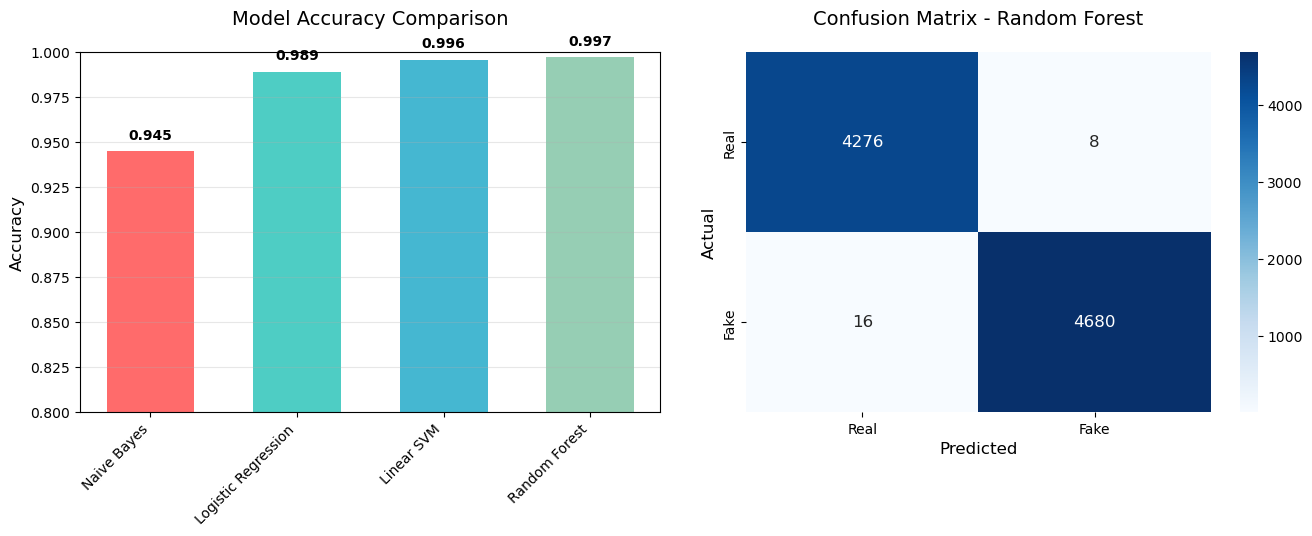


Best Model: Random Forest
Best Accuracy: 0.9973


In [16]:
# Visualize model comparison
plt.figure(figsize=(14, 6))

# Accuracy comparison
plt.subplot(1, 2, 1)
accuracies = [results[model]['accuracy'] for model in results]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Create positions for bars with more spacing
x_pos = np.arange(len(results))
bars = plt.bar(x_pos, accuracies, color=colors, width=0.6)

plt.title('Model Accuracy Comparison', fontsize=14, pad=20)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(x_pos, results.keys(), rotation=45, ha='right')
plt.ylim(0.8, 1.0)

# Add value labels on bars (adjusted position)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Confusion matrix for best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_pipeline = results[best_model_name]['pipeline']

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'],
            annot_kws={'size': 12})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, pad=20)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]['accuracy']:.4f}")

In [17]:
class FakeNewsDetector:
    """Production-ready fake news detection system"""
    
    def __init__(self, model_pipeline, preprocessor):
        self.pipeline = model_pipeline
        self.preprocessor = preprocessor
        self.threshold = 0.5  # Confidence threshold
    
    def predict(self, title, text):
        """Predict whether a news article is fake or real"""
        # Combine and preprocess
        combined_text = f"{title} {text}"
        cleaned_text = self.preprocessor.clean_text(combined_text)
        
        # Get prediction and probability
        prediction = self.pipeline.predict([cleaned_text])[0]
        
        # Get probability scores if available
        try:
            probabilities = self.pipeline.predict_proba([cleaned_text])[0]
            confidence = max(probabilities)
        except:
            confidence = 1.0
        
        result = {
            'prediction': 'Fake News' if prediction == 1 else 'Real News',
            'label': int(prediction),
            'confidence': float(confidence),
            'is_reliable': confidence >= self.threshold
        }
        
        return result
    
    def batch_predict(self, articles_df):
        """Predict for multiple articles"""
        predictions = []
        
        for _, row in articles_df.iterrows():
            pred = self.predict(row['title'], row['text'])
            predictions.append(pred)
        
        return predictions
    
    def analyze_article(self, title, text):
        """Detailed analysis of a news article"""
        result = self.predict(title, text)
        
        # Additional text analysis
        words = len(text.split())
        sentences = len([s for s in text.split('.') if s.strip()])
        avg_sentence_length = words / max(sentences, 1)
        
        analysis = {
            'prediction': result,
            'statistics': {
                'word_count': words,
                'sentence_count': sentences,
                'avg_sentence_length': round(avg_sentence_length, 2),
                'text_length': len(text)
            }
        }
        
        return analysis

# Initialize the detector with best model
detector = FakeNewsDetector(best_pipeline, preprocessor)

print("Fake News Detection System is ready!")

Fake News Detection System is ready!


In [18]:
# Test with sample news articles
def test_detector():
    """Test the detection system with various articles"""
    
    # Sample real and fake news
    test_articles = [
        {
            'title': 'Scientists Discover New Treatment for Cancer',
            'text': 'Researchers at Stanford University have published groundbreaking results showing a 90% success rate in treating advanced-stage cancer using a new immunotherapy approach.'
        },
        {
            'title': 'ALIENS LAND IN NEW YORK - Government Cover-Up Exposed!',
            'text': 'BREAKING: Multiple witnesses reported seeing UFOs landing in Times Square. The government is hiding the truth from citizens. Share this before they delete it!'
        },
        {
            'title': 'President Signs New Education Bill',
            'text': 'The president signed legislation today that will increase funding for public schools by 15% over the next three years, with a focus on STEM education programs.'
        }
    ]
    
    print("="*60)
    print("FAKE NEWS DETECTION SYSTEM - TEST RESULTS")
    print("="*60)
    
    for i, article in enumerate(test_articles, 1):
        result = detector.analyze_article(article['title'], article['text'])
        
        print(f"\nArticle {i}:")
        print(f"Title: {article['title'][:100]}...")
        print(f"Text Preview: {article['text'][:150]}...")
        print(f"\nPrediction: {result['prediction']['prediction']}")
        print(f"Confidence: {result['prediction']['confidence']:.2%}")
        print(f"Word Count: {result['statistics']['word_count']}")
        print("-"*40)

# Run the test
test_detector()

FAKE NEWS DETECTION SYSTEM - TEST RESULTS

Article 1:
Title: Scientists Discover New Treatment for Cancer...
Text Preview: Researchers at Stanford University have published groundbreaking results showing a 90% success rate in treating advanced-stage cancer using a new immu...

Prediction: Fake News
Confidence: 75.32%
Word Count: 22
----------------------------------------

Article 2:
Title: ALIENS LAND IN NEW YORK - Government Cover-Up Exposed!...
Text Preview: BREAKING: Multiple witnesses reported seeing UFOs landing in Times Square. The government is hiding the truth from citizens. Share this before they de...

Prediction: Fake News
Confidence: 71.55%
Word Count: 24
----------------------------------------

Article 3:
Title: President Signs New Education Bill...
Text Preview: The president signed legislation today that will increase funding for public schools by 15% over the next three years, with a focus on STEM education ...

Prediction: Fake News
Confidence: 71.93%
Word Count: 26


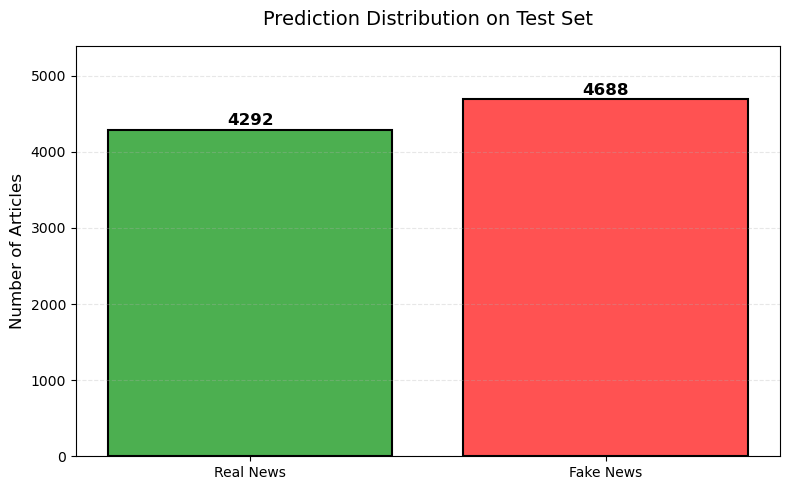

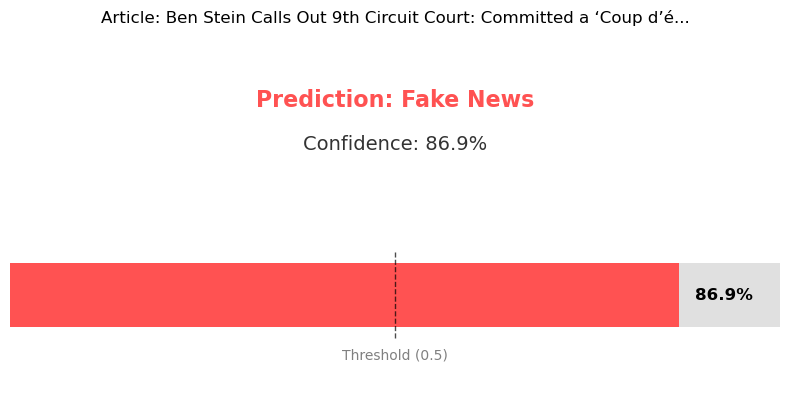


Visualization of Prediction Output completed!


In [19]:
# Visualization of Prediction Output (Fake/Real)

# 1. Get predictions for the entire test set (already computed)
y_pred = results[best_model_name]['predictions']

# 2. Bar chart: count of Fake vs Real predictions
plt.figure(figsize=(8, 5))
counts = pd.Series(y_pred).value_counts().sort_index()
labels = ['Real News', 'Fake News']
colors = ['#4CAF50', '#FF5252']

bars = plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Prediction Distribution on Test Set', fontsize=14, pad=15)
plt.ylabel('Number of Articles', fontsize=12)
plt.ylim(0, max(counts) * 1.15)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Visualize a single prediction with confidence bar
def visualize_single_prediction(title, text, detector):
    """Display a single prediction with a confidence bar."""
    result = detector.analyze_article(title, text)
    pred = result['prediction']['prediction']
    conf = result['prediction']['confidence']
    is_fake = pred == 'Fake News'
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), 
                                   gridspec_kw={'height_ratios': [1, 2]})
    
    # Top: title and prediction
    ax1.axis('off')
    ax1.text(0.5, 0.6, f"Prediction: {pred}", 
             fontsize=16, fontweight='bold', ha='center',
             color='#FF5252' if is_fake else '#4CAF50')
    ax1.text(0.5, 0.2, f"Confidence: {conf:.1%}", 
             fontsize=14, ha='center', color='#333')
    
    # Bottom: confidence bar
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')
    
    # Background bar (gray)
    ax2.barh(0.5, 1, height=0.3, color='#e0e0e0', edgecolor='none')
    
    # Colored confidence segment
    color = '#FF5252' if is_fake else '#4CAF50'
    ax2.barh(0.5, conf, height=0.3, color=color, edgecolor='none')
    
    # Add threshold markers
    ax2.axvline(x=0.5, ymin=0.3, ymax=0.7, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax2.text(0.5, 0.2, 'Threshold (0.5)', ha='center', fontsize=10, color='gray')
    
    # Label percentage
    ax2.text(conf + 0.02, 0.5, f'{conf:.1%}', va='center', fontsize=12, fontweight='bold')
    
    plt.suptitle(f"Article: {title[:60]}...", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Example: visualize a sample from the test set
sample_idx = 0  # change to any index
sample_title = df.iloc[sample_idx]['title']
sample_text = df.iloc[sample_idx]['text']
visualize_single_prediction(sample_title, sample_text, detector)

print("\nVisualization of Prediction Output completed!")

In [20]:
# Save the model and preprocessor
def save_model(detector, filename='fake_news_detector.pkl'):
    """Save the trained model for deployment"""
    model_data = {
        'pipeline': detector.pipeline,
        'vectorizer_config': {
            'max_features': 5000,
            'ngram_range': (1, 2)
        }
    }
    
    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)
    
    print(f"Model saved to {filename}")
    
    # Also save file size
    import os
    file_size = os.path.getsize(filename) / (1024 * 1024)
    print(f"Model file size: {file_size:.2f} MB")

# Save the model
save_model(detector)

# Function to load the model
def load_model(filename='fake_news_detector.pkl'):
    """Load the saved model"""
    with open(filename, 'rb') as f:
        model_data = pickle.load(f)
    
    # Recreate detector
    detector = FakeNewsDetector(model_data['pipeline'], TextPreprocessor())
    return detector

print("\n✓ Model saved and ready for deployment!")

Model saved to fake_news_detector.pkl
Model file size: 10.66 MB

✓ Model saved and ready for deployment!


In [21]:
def interactive_mode():
    """Run interactive fake news checking"""
    print("\n" + "="*60)
    print("FAKE NEWS DETECTION SYSTEM - INTERACTIVE MODE")
    print("="*60)
    print("Type 'quit' to exit\n")
    
    while True:
        print("\n" + "-"*40)
        title = input("Enter news title (or 'quit' to exit): ")
        
        if title.lower() == 'quit':
            break
        
        text = input("Enter news text: ")
        
        if text.lower() == 'quit':
            break
        
        # Make prediction
        result = detector.analyze_article(title, text)
        
        print("\n" + "="*40)
        print("ANALYSIS RESULT")
        print("="*40)
        print(f"Prediction: {result['prediction']['prediction']}")
        print(f"Confidence: {result['prediction']['confidence']:.2%}")
        print(f"Reliability: {'HIGH' if result['prediction']['confidence'] >= 0.7 else 'LOW'}")
        print(f"\nText Statistics:")
        print(f"  - Words: {result['statistics']['word_count']}")
        print(f"  - Sentences: {result['statistics']['sentence_count']}")
        print(f"  - Avg Sentence Length: {result['statistics']['avg_sentence_length']}")

# Uncomment to run interactive mode
# interactive_mode()

In [22]:
def print_system_summary():
    """Print complete summary of the detection system"""
    
    print("\n" + "="*60)
    print("FAKE NEWS DETECTION SYSTEM - COMPLETE SUMMARY")
    print("="*60)
    
    print("\n Dataset Statistics:")
    print(f"  Total Articles: {len(df)}")
    print(f"  Fake News: {df['label'].sum()} ({(df['label'].sum()/len(df))*100:.1f}%)")
    print(f"  Real News: {len(df)-df['label'].sum()} ({((len(df)-df['label'].sum())/len(df))*100:.1f}%)")
    
    print("\n Model Performance:")
    for model_name, result in results.items():
        print(f"  {model_name}: {result['accuracy']:.4f}")
    
    print(f"\n Best Model: {best_model_name}")
    print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
    
    print("\n System Features:")
    print("  ✓ Text cleaning and preprocessing")
    print("  ✓ TF-IDF vectorization with n-grams")
    print("  ✓ Multiple ML algorithms compared")
    print("  ✓ Confidence scoring")
    print("  ✓ Batch processing capability")
    print("  ✓ Model persistence (save/load)")
    print("  ✓ Interactive detection interface")
    
    print("\n Saved Files:")
    print("  - fake_news_detector.pkl (Trained model)")
    print("  - model_evaluation.png (Performance visualization)")
    
    print("\n" + "="*60)
    print("System is ready for deployment! 🚀")
    print("="*60)

# Print final summary
print_system_summary()


FAKE NEWS DETECTION SYSTEM - COMPLETE SUMMARY

 Dataset Statistics:
  Total Articles: 44898
  Fake News: 23481 (52.3%)
  Real News: 21417 (47.7%)

 Model Performance:
  Naive Bayes: 0.9450
  Logistic Regression: 0.9891
  Linear SVM: 0.9958
  Random Forest: 0.9973

 Best Model: Random Forest
  Accuracy: 0.9973

 System Features:
  ✓ Text cleaning and preprocessing
  ✓ TF-IDF vectorization with n-grams
  ✓ Multiple ML algorithms compared
  ✓ Confidence scoring
  ✓ Batch processing capability
  ✓ Model persistence (save/load)
  ✓ Interactive detection interface

 Saved Files:
  - fake_news_detector.pkl (Trained model)
  - model_evaluation.png (Performance visualization)

System is ready for deployment! 🚀
